## Brownian motion to smooth time series curve

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta, norm, kstest
from sklearn.metrics import mean_squared_error
import warnings
from scipy.interpolate import make_splrep
import random
from datetime import datetime, timedelta

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../../data/processed/dataset_clean_no-outliers.csv').drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'price', 'load'])
df['speed'] = df['speed'][6:].reset_index(drop=True)
df['power'] = df['power'][:-6].reset_index(drop=True)
normalized = (df['power'] - df['power'].min()) / (df['power'].max() - df['power'].min()) # normalize
df['npower'] = np.clip(normalized, 1e-15, 1 - 1e-15)
df.dropna(inplace=True)

In [4]:
df

,datetime,speed,power,npower
0,2020-01-01 01:00:00,8.143577,10827.38,0.570237
1,2020-01-01 02:00:00,8.668293,11527.36,0.607128
2,2020-01-01 03:00:00,9.599056,12100.85,0.637352
3,2020-01-01 04:00:00,11.014150,12780.48,0.673170
4,2020-01-01 05:00:00,10.188864,13064.80,0.688154
...,...,...,...,...
43798,2024-12-31 13:00:00,4.426382,2745.43,0.144300
43799,2024-12-31 14:00:00,3.905590,1524.70,0.079965
43800,2024-12-31 15:00:00,3.856292,821.43,0.042901
43801,2024-12-31 16:00:00,3.379553,490.65,0.025468


In [5]:
def fit_params_spline(speed, power, intervals, k, s):
    params = pd.DataFrame(columns=['avg_speed', 'a', 'b', 'loc', 'scale'])
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        avg_speed = (lower + upper) / 2
        filtered_power = power[(speed >= lower) & (speed < upper)]
        params.loc[len(params)] = [avg_speed] + list(beta.fit(filtered_power, floc=0, fscale=1))

    # a_spline = UnivariateSpline(params['avg_speed'], params['a'], k=k, s=s)
    # b_spline = UnivariateSpline(params['avg_speed'], params['b'], k=k, s=s)
    a_spline = make_splrep(np.array(params['avg_speed']), np.array(params['a']), k=k, s=s)
    b_spline = make_splrep(np.array(params['avg_speed']), np.array(params['b']), k=k, s=s)

    return a_spline, b_spline

In [ ]:
# lowers = np.array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
#          5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
#         11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
#         16.5])
# uppers = np.array([ 0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,
#          6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. ,
#         11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5,
#         20. ])

In [6]:
lowers = np.array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17])
uppers = np.array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        20])

In [7]:
def fit(speeds, power, lowers, uppers, k, s):
    #power = self.normalize_power(power)

    params = pd.DataFrame(columns=['avg_speed', 'a', 'b', 'loc', 'scale'])
    num_intervals = len(lowers)

    for i in range(num_intervals):
        lower = lowers[i]
        upper = uppers[i]
        avg_speed = (lower + upper) / 2
        filtered_power = power[(speeds >= lower) & (speeds < upper)]
        params.loc[len(params)] = [avg_speed] + list(beta.fit(filtered_power, floc=0, fscale=1))

    a_spline = make_splrep(np.array(params['avg_speed']), np.array(params['a']), k=k, s=s)
    b_spline = make_splrep(np.array(params['avg_speed']), np.array(params['b']), k=k, s=s)

    return a_spline, b_spline

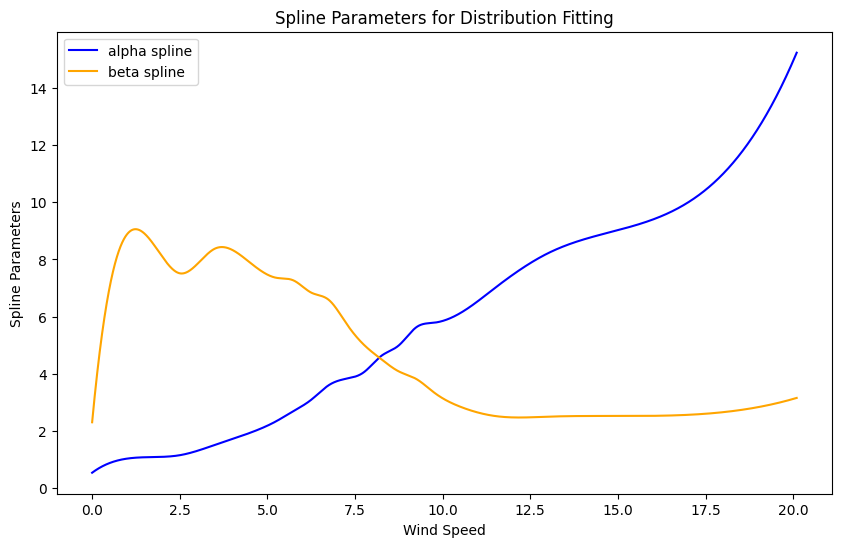

In [8]:
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
k = 3
s = 0
# a_spline, b_spline = fit(speed, normalized_power, lowers, uppers, k=k, s=s)
a_spline, b_spline = fit_params_spline(df['speed'], df['npower'], intervals, k=k, s=s)

x = np.linspace(0, 20.1, 10000)
y_a = a_spline(x)
y_b = b_spline(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y_a, label='alpha spline', color='blue')
plt.plot(x, y_b, label='beta spline', color='orange')
# plt.scatter(intervals[:-1], [a_spline(i) for i in intervals[:-1]], color='blue', marker='o', label='a_spline points')
# plt.scatter(intervals[:-1], [b_spline(i) for i in intervals[:-1]], color='orange', marker='o', label='b_spline points')
plt.title('Spline Parameters for Distribution Fitting')
plt.xlabel('Wind Speed')
plt.ylabel('Spline Parameters')
plt.legend()

In [9]:
a_spline(20)

array(14.94694177)

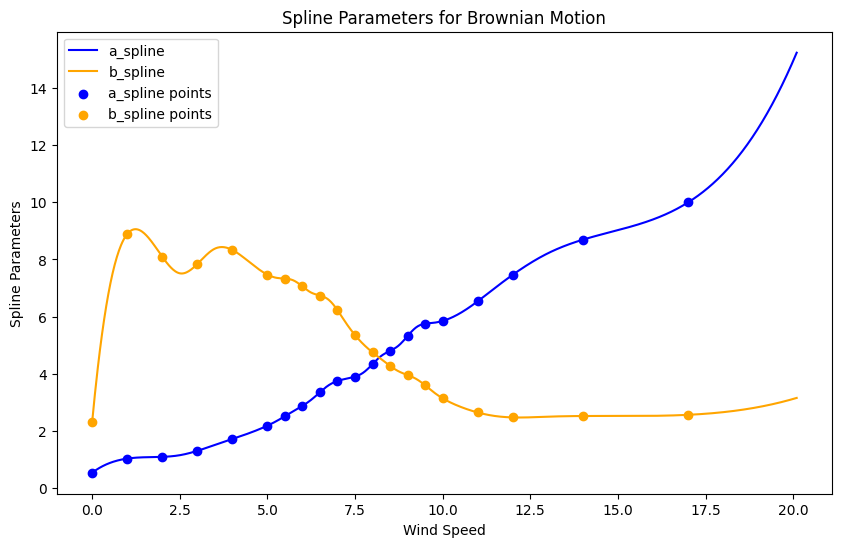

In [10]:
x = np.linspace(0, 20.1, 1000)
y_a = a_spline(x)
y_b = b_spline(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y_a, label='a_spline', color='blue')
plt.plot(x, y_b, label='b_spline', color='orange')
plt.scatter(intervals[:-1], [a_spline(i) for i in intervals[:-1]], color='blue', marker='o', label='a_spline points')
plt.scatter(intervals[:-1], [b_spline(i) for i in intervals[:-1]], color='orange', marker='o', label='b_spline points')
plt.title('Spline Parameters for Brownian Motion')
plt.xlabel('Wind Speed')
plt.ylabel('Spline Parameters')
plt.legend()

In [11]:
def get_all_distributions(df, intervals):
    fitted_distributions = {}
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        power = df[(df['speed'] >= lower) & (df['speed'] < upper)]['power']

        params = beta.fit(power, floc=0, fscale=20000)
        p = kstest(power, 'beta', args=params)[1]

        fitted_distributions[f'{lower}-{upper}'] = {
            'params': params,
            'p_value': p
        }
        
    return fitted_distributions

In [ ]:
# splines, but without brownian motion
# def pred_power(speeds, a_spline, b_spline):
#     pred_powers = []
#     for speed in speeds:
#         a = a_spline(speed)
#         b = b_spline(speed)
#         pred_power = beta.rvs(a, b, loc=0, scale=20000)
#         pred_powers.append(pred_power)
#     return np.array(pred_powers)

In [22]:
# brownian motion without splines
def pred_power_b(speeds, fitted_distributions, intervals, smoothing_factor, drift_factor):
    predictions = []
    prev_w = None # w is the inverse CDF input to get the sampled power

    for speed in speeds:
        for i in range(len(intervals) - 1):
            lower = intervals[i]
            upper = intervals[i + 1]
            if lower <= speed < upper:
                params = fitted_distributions[f'{lower}-{upper}']['params']

                if prev_w is None:
                    w = np.random.rand(1)[0]
                else:
                    # use previous w to smooth the current w; brownian motion
                    smoothing_condition = smoothing_factor * norm.rvs(0, 1, size=1)[0]
                    drift_condition = drift_factor * (0.5 - prev_w) # drift towards median 0.5
                    w = prev_w + smoothing_condition + drift_condition
                    # ensure w stays within [0, 1]
                    w = max(0, min(w, 1))
                
                prev_w = w
                sample = beta.ppf(w, *params)

                # avoid sampling out of the range 0 to 20000
                #sampled_power = max(0, min(sampled_power, 20000))

                predictions.append(sample)
                break
    return predictions

In [23]:
# brownian motion with splines
def pred_power_bs(speeds, a_spline, b_spline, smoothing_factor=0.01, drift_factor=0.001, reset_prev_w=0.02):
    predictions = []
    prev_w = None  # w is the inverse CDF input to get the sampled power
    reset_counter = 0

    for speed in speeds:
        a = a_spline(speed)
        b = b_spline(speed)

        if prev_w is None or random.random() < reset_prev_w:
            w = np.random.rand(1)[0]
            reset_counter += 1
        else:
            # use previous w to smooth the current w; brownian motion
            smoothing_condition = norm.rvs(0, 1, size=1)[0] * smoothing_factor
            drift_condition = drift_factor * (0.5 - prev_w) # drift towards median 0.5
            w = prev_w + smoothing_condition + drift_condition
            # ensure w stays within [0, 1]
            if w < 0: w = -w
            if w > 1: w = 2-w

        prev_w = w
        pred = beta.ppf(w, a, b, loc=0, scale=1)
        predictions.append(pred)
    
    print(f"Reset counter: {reset_counter}")

    return predictions

In [24]:
# old; brownian motion without splines
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20.1]
fitted = get_all_distributions(df, intervals)
preds = pred_power_b(df['speed'], fitted, intervals, smoothing_factor=0.01, drift_factor=0.001)
df_brownian = pd.DataFrame({'time_stamp': df['datetime'], 'speed': df['speed'], 'power': preds, 'historical_power': df['power']})

In [26]:
# brownian motion with splines
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
a_spline, b_spline = fit_params_spline(df['speed'], df['npower'], intervals, 3, 0)
preds = pred_power_bs(df['speed'], a_spline, b_spline, smoothing_factor=0.01, drift_factor=0.001)
df_brownian_spline = pd.DataFrame({'time_stamp': df['datetime'], 'speed': df['speed'], 'power': preds, 'historical_power': df['npower']})

Reset counter: 867


Text(0, 0.5, 'Power (Normalized)')

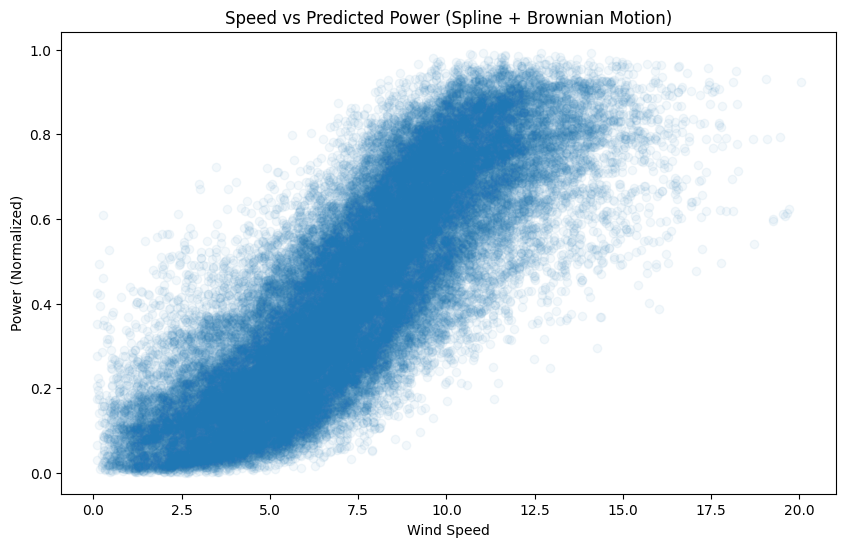

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df_brownian_spline['speed'], df_brownian_spline['power'], alpha=0.05)
plt.title('Speed vs Predicted Power (Spline + Brownian Motion)')
plt.xlabel('Wind Speed')
plt.ylabel('Power (Normalized)')

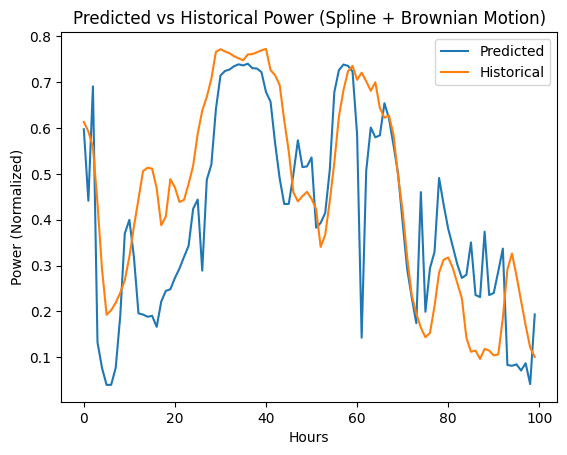

In [28]:
plt.plot(df_brownian_spline['power'][20000:20100].reset_index(drop=True), label='Predicted')
plt.plot(df_brownian_spline['historical_power'][20000:20100].reset_index(drop=True), label='Historical')
plt.xlabel('Hours')
plt.ylabel('Power (Normalized)')
plt.title('Predicted vs Historical Power (Spline + Brownian Motion)')
plt.legend()

In [29]:
mean_squared_error(df_brownian_spline['historical_power'], df_brownian_spline['power'])

0.03780144315787854

Text(0, 0.5, 'Power Output')

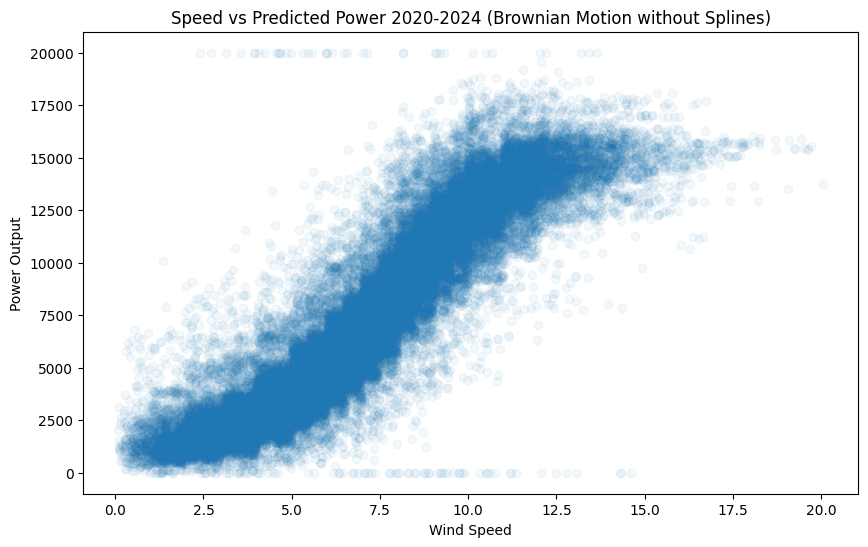

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df_brownian['speed'], df_brownian['power'], alpha=0.05)
plt.title('Speed vs Predicted Power 2020-2024 (Brownian Motion without Splines)')
plt.xlabel('Wind Speed')
plt.ylabel('Power Output')

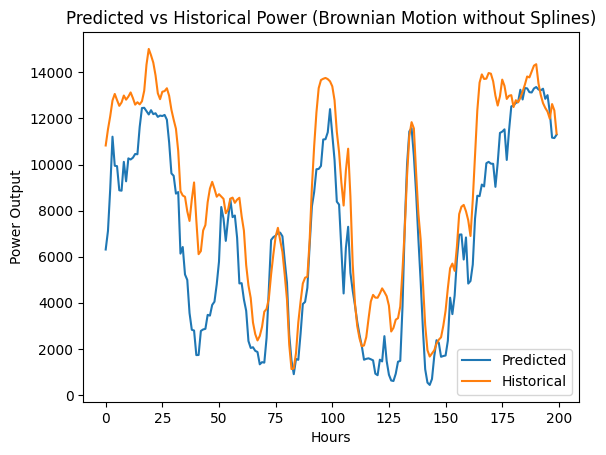

In [33]:
plt.plot(df_brownian['power'][0:200].reset_index(drop=True), label='Predicted')
plt.plot(df_brownian['historical_power'][0:200].reset_index(drop=True), label='Historical')
plt.xlabel('Hours')
plt.ylabel('Power Output')
plt.title('Predicted vs Historical Power (Brownian Motion without Splines)')
plt.legend()

# save to csv for we-validate

In [36]:
df.rename(columns={'datetime': 'time_stamp'}, inplace=True)

In [ ]:
def reformatHour24(date):
    # change hour 24 to hour 00 of next day
    if "24:00:00" in date:
        dt = date[:-8] + '00:00:00'
        dt = datetime.strptime(dt, '%Y-%m-%d %H:%M:%S')
        dt += timedelta(days=1)
        return dt.strftime('%Y-%m-%d %H:%M:%S')
    else:
        return date

df['time_stamp'] = df['time_stamp'].map(reformatHour24)
df_brownian_spline['time_stamp'] = df_brownian_spline['time_stamp'].map(reformatHour24)
df_brownian['time_stamp'] = df_brownian['time_stamp'].map(reformatHour24)

In [ ]:
# generate time_stamps in order for we-validate compatibility
def generate_time_stamps(start_date):
    current = start_date
    time_stamps = []
    while len(time_stamps) < 43803:
        time_stamps.append(current.strftime('%Y-%m-%d %H:%M:%S'))
        current += timedelta(hours=1)
    return time_stamps

In [74]:
time_stamp = generate_time_stamps(datetime(2020, 1, 1, 1, 0, 0))

In [82]:
df['time_stamp'] = time_stamp
df_brownian_spline['time_stamp'] = time_stamp
df_brownian['time_stamp'] = time_stamp

In [84]:
df.to_csv('results/ERCOT_historical_zonal.csv', index=False)
df_brownian_spline.to_csv('results/brownian_spline_results.csv', index=False)
df_brownian.to_csv('results/brownian_results.csv', index=False)